In [20]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

BG = "#0B1020"
PANEL = "#111827"
GRID = "#1F2937"
TEXT = "#E5E7EB"
MINT = "#2DD4BF"
MINT_LIGHT = "#99F6E4"
BLUE = "#60A5FA"
PINK = "#F472B6"
YELLOW = "#FBBF24"
PURPLE = "#A78BFA"

plotly_layout = dict(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(color=TEXT, size=13),
    title=dict(font=dict(size=22, color=TEXT)),
    xaxis=dict(gridcolor=GRID, zerolinecolor=GRID),
    yaxis=dict(gridcolor=GRID, zerolinecolor=GRID),
    colorway=[MINT, BLUE, PINK, YELLOW, PURPLE],
    margin=dict(l=50, r=40, t=70, b=50)
)

# 2. Exploratory Data Analysis (EDA)

## 2.1 Introduction
 After collecting the hand images and converting them into structured numerical landmark representations (21 three-dimensional keypoints per sample), our next step was to perform Exploratory Data Analysis (EDA).

We first wanted to look inside the data: how it is structured, how variable it is, where potential weaknesses might be, and what patterns are hidden behind these numbers.

In general, we aimed to examine: the overall structure of the dataset, whether the classes are balanced, if there are missing values or duplicates, how different users influence hand coordinates, how much variation exists within each gesture, which letters might be geometrically similar and therefore confusing for a model, and whether the feature space looks separable enough for reliable classification.

Essentially, EDA served as a foundation check: to make sure the dataset is clean, consistent, and truly suitable for building a stable and generalizable sign language recognition model.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

df = pd.read_csv("landmarks_merged.csv")
df['source'] = df['source'].replace({'self_collected_pavel': 'self_collected_pasha'})

feat_cols = [c for c in df.columns if c.startswith(('x', 'y', 'z'))]
df['hand_size'] = np.sqrt(df['x9']**2 + df['y9']**2 + df['z9']**2)

print('Shape:', df.shape)
print(df.head())

#### Here we can clearly see what the raw dataset looks like in practice.

Each row represents one ASL hand sample, and each column corresponds to a landmark coordinate (x, y, z) or metadata (letter, source).

From this output we confirm:

The dataset contains 33,892 samples and 65 columns.
Landmark x0, y0, z0 are all zeros, meaning the wrist is used as the origin (relative coordinate normalization).
All other landmarks are stored as relative 3D coordinates.
Each sample is labeled with a target class (letter).
The source column identifies the data origin (e.g., self-collected user data).

## 2.2 Dataset Overview 
This block is needed to quickly understand the data structure: what classes (letters) are there, what source data is used, and whether there are any missing values. 

### 2.2.1 Distribution Check


Missing values:
 x0        0
y0        0
z0        0
x1        0
y1        0
         ..
x20       0
y20       0
z20       0
letter    0
source    0
Length: 65, dtype: int64

Class distribution:
 letter
F         1511
K         1442
V         1410
Y         1407
L         1407
R         1405
S         1405
U         1391
W         1389
G         1369
D         1361
I         1337
H         1336
T         1327
E         1306
B         1304
O         1290
A         1271
X         1270
Q         1263
P         1221
C         1212
DELETE    1138
M         1088
SPACE     1053
N          979
Name: count, dtype: int64

Sources:
 source
kaggle_alphabet           19592
self_collected_akezhun     5200
self_collected_akira       2600
self_collected_i2          2600
self_collected_pavel       2600
self_collected_pasha       1300
Name: count, dtype: int64


<Axes: xlabel='letter'>

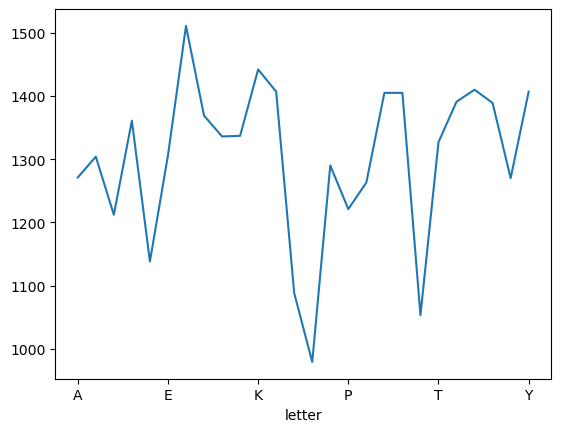

In [23]:
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['letter'].value_counts())
print("\nSources:\n", df['source'].value_counts())

df['letter'].value_counts().sort_index().plot()


### 2.2.2 Leak Checking

In [24]:
print('Missing values:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Number of classes:', df['letter'].nunique())
print('Number of sources:', df['source'].nunique())


Missing values: 0
Duplicate rows: 0
Number of classes: 26
Number of sources: 6


### 2.2.3 Sample Size Difference

In [25]:
counts = df['letter'].value_counts()
print('Minimum class size:', counts.min())
print('Maximum class size:', counts.max())
print('Imbalance ratio:', counts.max() / counts.min())

Minimum class size: 979
Maximum class size: 1511
Imbalance ratio: 1.54341164453524


#### Thoughts

As we can see, during the data collection and merging of all samples into a single dataset, no issues occurred and everything was preserved correctly.

There are no duplicates or missing values. Although we can notice a few potential issues, I will return to them later. At the moment, the most noticeable aspect is the difference in the number of samples between different letters.

This variation is not extremely large, but it is still visible and may slightly affect model performance for less represented classes. Overall, however, the dataset remains relatively balanced and suitable for training a classification model without additional heavy resampling techniques.

## 2.3 Class Distribution Analysis

Accordingly, we expand the point we noted in the previous section. Here we can graphically visually understand the difference in the number of letters and, in general, understand the scale of the problem.

### 2.3.1 Samples per ASL Class

In [35]:
counts = df['letter'].value_counts().sort_index().reset_index()
counts.columns = ['letter', 'count']

fig = px.bar(
    counts,
    x='letter',
    y='count',
    text='count',
    color='count',
    color_continuous_scale=['#134E4A', '#2DD4BF', '#99F6E4'],
)

fig.update_traces(textposition='outside')
fig.update_layout(**plotly_layout)
fig.show()

#### Relatively balanced

Class sizes ranging approximately from 950 to 1500 samples. Some classes such as N and SPACE have slightly fewer samples compared to others, but mostly the difference is not severe enough to indicate strong class imbalance. So the scale of the problem is not that huge.

### 2.3.2 Class Coverage by Data Source

In [57]:
source_letter = pd.crosstab(df['letter'], df['source'])

fig = px.imshow(
    source_letter,
    color_continuous_scale=['#0B1020', '#134E4A', '#2DD4BF', '#99F6E4'],
    aspect='auto',
)

fig.update_layout(**plotly_layout)
fig.update_xaxes(title='Source')
fig.update_yaxes(title='Class')
fig.show()

In general, here we can understand what exactly is going on. In data collection, we decided to take a pre-existing dataset and additionally supplement it with our own samples. And most likely, since we were working with code that collects a fixed number of images, our own part of the dataset is mostly stable in terms of counts. The main differences between letters in sample size come more from the original dataset, where there is a larger variation between classes.

### 2.3.3 Data Source Distribution

In [43]:
source_counts = df['source'].value_counts().reset_index()
source_counts.columns = ['source', 'count']

fig = px.bar(
    source_counts,
    x='source',
    y='count',
    text='count',
    color='source',
)

fig.update_traces(textposition='outside')
fig.update_layout(**plotly_layout, showlegend=False)
fig.update_xaxes(tickangle=35)
fig.show()

We can clearly see the impact of each participant on the data. We increased the dataset by approximately 74.4%, which will have a very positive impact on subsequent work with the models.

## 2.4 Landmark Feature Statistics

We analyze statistical properties of landmark coordinates to understand their range, spread, and normalization quality.

In [34]:
summary = df[feat_cols].describe().T[['mean','std','min','25%','50%','75%','max']]
summary

,mean,std,min,25%,50%,75%,max
x0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
y0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
z0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
x1,0.025743,0.083107,-0.212600,-0.052354,0.045033,0.092751,0.241326
y1,-0.056048,0.048185,-0.253647,-0.082705,-0.057331,-0.034309,0.162619
...,...,...,...,...,...,...,...
y19,-0.200013,0.162927,-0.735708,-0.292433,-0.194562,-0.121992,0.562256
z19,-0.082648,0.060731,-0.831210,-0.111133,-0.076776,-0.048478,0.266896
x20,-0.030983,0.142371,-0.602732,-0.083278,-0.030165,0.046095,0.577315
y20,-0.184919,0.179314,-0.833382,-0.281934,-0.155459,-0.092760,0.635785




x0, y0, z0 are all 0 → this is the wrist reference point (origin)
Other landmarks have:
* small mean values close to 0 → data is normalized
* different std values → different motion ranges per joint
* wide min/max range → variation in hand positions

Some joints vary much more than others, these carry more discriminative information. Therefore It is worth looking at the influence of each joint to understand how important some joints are. 

ALso this confirms MediaPipe preprocessing is consistent and suitable for ML.
Overall, features are well-scaled and informative for classification.

## 2.5 Landmark Importance (Variance)
We understood that each joint can have a significant role or even a little analytical value. This can be seen clearly here.

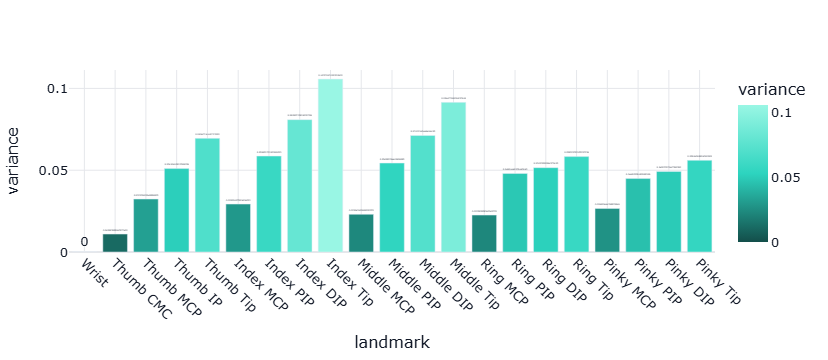

In [38]:
landmark_var = []
for i in range(21):
    v = df[f'x{i}'].var() + df[f'y{i}'].var() + df[f'z{i}'].var()
    landmark_var.append(v)

names = [
    "Wrist",
    "Thumb CMC","Thumb MCP","Thumb IP","Thumb Tip",
    "Index MCP","Index PIP","Index DIP","Index Tip",
    "Middle MCP","Middle PIP","Middle DIP","Middle Tip",
    "Ring MCP","Ring PIP","Ring DIP","Ring Tip",
    "Pinky MCP","Pinky PIP","Pinky DIP","Pinky Tip"
]

var_df = pd.DataFrame({
    "landmark": names,
    "variance": landmark_var
})

fig = px.bar(
    var_df,
    x='landmark',
    y='variance',
    text='variance',
    color='variance',
    color_continuous_scale=['#134E4A', MINT, MINT_LIGHT],
)

fig.update_traces(textposition='outside')
fig.update_layout(**plotly_layout)
fig.update_xaxes(tickangle=45)

fig.show()



Wrist has 0 variance cause it's the fixed reference point

Fingers (especially index and middle fingertips) show the highest variance. Thumb and ring finger have moderate variation while Pinky shows relatively lower variation

Fingertips carry the most information and they are critical for classification. Higher variance means more movement across gestures → more discriminative power. Lower variance joints contribute less to class separation

The model will mainly rely on finger tip and PIP/DIP joints, which confirms that landmark-based representation is meaningful for ASL recognition.

## 2.6 Hand Size Influence 
Since we realized that hand size also influences the analysis, here we demonstrated the variability of each source



### 2.6.1 Variability Across Data Sources

In [44]:
fig = px.box(
    df,
    x='source',
    y='hand_size',
    color='source',
    points='outliers',
)

fig.update_layout(**plotly_layout, showlegend=False)
fig.update_xaxes(tickangle=35)
fig.show()



Kaggle samples show smaller and more compact hand sizes
Self-collected datasets have more variable hand sizes and median values differ slightly across sources because everyone did it independently of each other.

Yes, there is a clear source-dependent variation in hand scale and it means the model must generalize across different camera setups and users. But variation is not extreme.


### 2.6.2 Distribution of Hand Size (User Variation)

In [54]:
fig = px.histogram(
    df,
    x='hand_size',
    nbins=60,
    color_discrete_sequence=[MINT],
    marginal='box',
    opacity=0.85,
)

fig.update_layout(**plotly_layout)
fig.show()


The hand size distribution shows that most values are concentrated in the range of ~0.2–0.35, the dataset is fairly consistent in scale after normalization. There is still some variation (from ~0.05 to ~0.68), which reflects differences between users and recording conditions.

This is important because the model should be invariant to hand scale, focusing on gesture shape rather than absolute size.

### 2.6.3 Hand Pose Variability (Gesture Complexity)

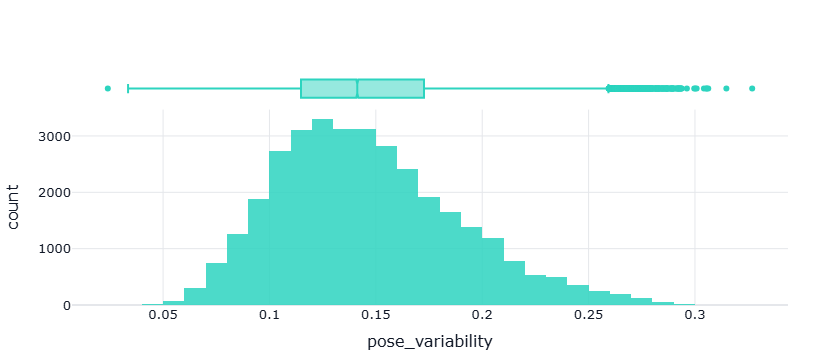

In [51]:
df['pose_variability'] = np.sqrt(
    df[[f'x{i}' for i in range(21)]].var(axis=1) +
    df[[f'y{i}' for i in range(21)]].var(axis=1)
)

fig = px.histogram(
    df,
    x='pose_variability',
    nbins=60,
    color_discrete_sequence=[MINT],
    marginal='box',
    opacity=0.85,
)

fig.update_layout(**plotly_layout)
fig.show()

The pose variability distribution is centered around ~0.14 with a relatively smooth spread.

This indicates that simpler gestures have lower variability, while more complex signs show higher variation. This feature is therefore directly related to gesture complexity and potential classification difficulty.

## 2.7 Sign Difficulty Analysis (Intra-Class Variability)
One more point that can affect the analysis

Some signs have very consistent hand shapes across different samples, while others are significantly depending on hand position, orientation, and so on.

So we want to determine the difficulty of each sign

In [59]:
difficulty = df.groupby('letter')[feat_cols].std().mean(axis=1).reset_index()
difficulty.columns = ['letter', 'std']
difficulty = difficulty.sort_values('std')

fig = px.bar(
    difficulty,
    x='letter',
    y='std',
    text='std',
    color='std',
    color_continuous_scale=['#134E4A', '#2DD4BF', '#99F6E4'],
)

fig.update_traces(textposition='outside')
fig.update_layout(**plotly_layout)
fig.show()


The class DELETE has one of the highest variability values.
The class R has one of the lowest variability values.
<img src="https://media.istockphoto.com/id/185257780/photo/punching-fist.jpg?s=612x612&w=0&k=20&c=0Wi_KYIns6HIdEUoBX6idWQx-j0EDuI85mFZrd7SCAw=" width="300"/>

DELETE (fist-like gesture) is relatively simple and can be performed in many slightly different ways depending on hand tightness, angle, or camera view. This leads to higher variability in landmark positions.

<img src="https://static.vecteezy.com/system/resources/previews/027/394/576/large_2x/letter-r-in-american-sign-language-asl-for-deaf-people-photo.jpg" width="300"/>

R, on the other hand, is a more structured finger configuration with less natural variation, so its landmark representation is more consistent across samples

#### How this affects machine learning:

High-variability classes (like DELETE) are harder to model, cause of the same labels can look geometrically different across samples.
Low-variability classes (like R) are easier to learn, since their feature space is more compact and consistent.



## 2.8 Feature Space Structure & Class Separability
This section analyzes how well different ASL gestures are separated in the landmark-feature space.

### 2.8.1 Inter-Class Distance (Confusability Map)
We construct a matrix of interclass distances to finally understand different ASL letters that are similar to each other.

* Dark values (small distance) → letters are similar in shape to the hand
* Light values (large distance) → letters are very different

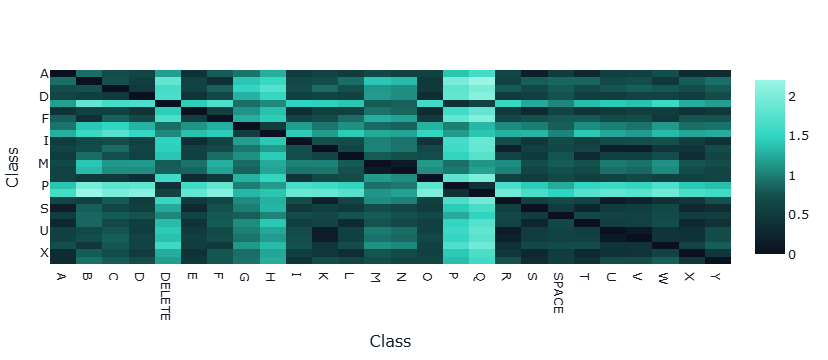

In [61]:
from sklearn.metrics import pairwise_distances

feat_cols = [c for c in df.columns if c.startswith(('x','y','z'))]
df['letter'] = df['letter'].astype(str)

class_means = df.groupby('letter')[feat_cols].mean()
dist_matrix = pairwise_distances(class_means.values)

fig = px.imshow(
    dist_matrix,
    x=class_means.index,
    y=class_means.index,
    color_continuous_scale=['#0B1020', '#134E4A', '#2DD4BF', '#99F6E4'],
    aspect='auto'
)

fig.update_layout(**plotly_layout)
fig.update_xaxes(title='Class')
fig.update_yaxes(title='Class')

fig.show()

Matrix shows that some ASL letters form tight clusters in landmark space (e.g., K–U–V, M–N, S–A), meaning their hand poses are very similar. These classes are expected to be the main source of classification errors. On the other hand, letters like DELETE and Q are well separated, which should lead to higher classification accuracy for those classes.

### 2.8.2 PCA Projection of ASL Landmark Space
The main goal is to understand whether ASL classes form separable structures in the feature space.
If different letters cluster in PCA space, it indicates that the landmark representation contains meaningful information for classification.

This also helps us evaluate how much information is preserved when reducing dimensionality.

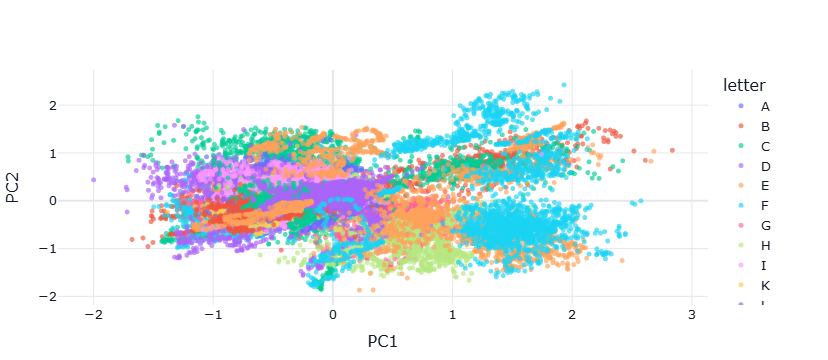

Variance explained by PC1 and PC2: 70.78%


In [63]:
from sklearn.decomposition import PCA

X = df[feat_cols].values.astype(np.float32)
y = df['letter'].values

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'letter': y,
    'source': df['source'].values
})

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='letter',
    hover_data=['source'],
    opacity=0.65,
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(**plotly_layout)

fig.show()

print(f'Variance explained by PC1 and PC2: {pca.explained_variance_ratio_.sum() * 100:.2f}%')

Some letter classes form partially visible clusters, indicating that landmark geometry is informative for classification.

There is still overlap between many classes, which is expected since PCA reduces nonlinear relationships into a linear projection. The relatively high explained variance (70.78%) suggests that the dataset has redundancy in landmark features.

#### ML relevance:

PCA confirms that the model does not rely on random noise — there is structured separability in the data.
Overlapping regions in PCA space explain why some classes may still be confused in classification results.
The high variance captured in 2 components supports the idea that dimensionality reduction methods (or feature compression) could be effective.

### 2.8.3 t-SNE Projection of ASL Landmark Features
 
t-SNE focuses on preserving local structure, meaning it is better at revealing clusters of similar samples.

For ASL recognition, this helps us understand whether visually similar gestures naturally form clusters in the learned landmark feature space.

We also use a subset of 4000 samples to reduce computational cost while maintaining representative structure.

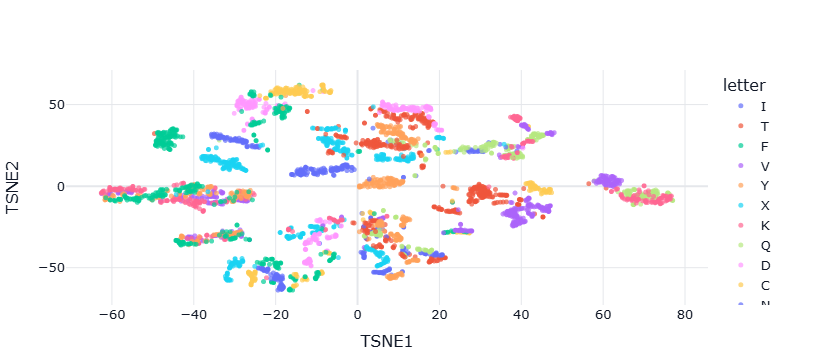

In [66]:
from sklearn.manifold import TSNE

np.random.seed(42)
n_samples = min(4000, len(X))
idx = np.random.choice(len(X), n_samples, replace=False)

tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    init='pca',
    learning_rate='auto',
    random_state=42
)

X_tsne = tsne.fit_transform(X[idx])

tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'letter': y[idx],
    'source': df['source'].values[idx]
})

fig = px.scatter(
    tsne_df,
    x='TSNE1',
    y='TSNE2',
    color='letter',
    hover_data=['source'],
    opacity=0.7,
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(**plotly_layout)

fig.show()

These wide ranges are expected because t-SNE does not preserve absolute scale — only relative distances between points.

#### Key observations:
This further confirms the strong discriminative power of the landmark features.
Some classes overlap significantly, which suggests visually or geometrically similar gestures.
Samples from different sources (Kaggle and self-collected data) are distributed within the same clusters, showing good feature alignment across datasets.
Certain signs such as similar finger configurations tend to appear closer together, which may explain classification errors in the final model.
#### ML relevance:
This visualization helps explain why models like SVM or Random Forest achieve high but not perfect accuracy.
The clustering pattern supports the idea that landmark-based features are sufficient for building a real-time ASL recognition system.

### 2.8.4 Mean Hand Pose per Class

Averaging landmark positions per class shows the typical hand shape for each gesture. Signs like M, N, and S appear geometrically close, consistent with what the confusability matrix shows.

In [ ]:
from plotly.subplots import make_subplots

CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17),
]

letters = sorted(df['letter'].unique())
n_cols = 6
n_rows = -(-len(letters) // n_cols)

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=letters,
    horizontal_spacing=0.03,
    vertical_spacing=0.07,
)

for idx, letter in enumerate(letters):
    r, col = idx // n_cols + 1, idx % n_cols + 1
    sub = df[df['letter'] == letter]
    xs = [sub[f'x{j}'].mean() for j in range(21)]
    ys = [-sub[f'y{j}'].mean() for j in range(21)]

    for a, b in CONNECTIONS:
        fig.add_trace(go.Scatter(
            x=[xs[a], xs[b]], y=[ys[a], ys[b]],
            mode='lines',
            line=dict(color=MINT, width=1.5),
            showlegend=False,
        ), row=r, col=col)

    fig.add_trace(go.Scatter(
        x=xs, y=ys,
        mode='markers',
        marker=dict(color=MINT_LIGHT, size=5),
        showlegend=False,
    ), row=r, col=col)

fig.update_layout(**plotly_layout, height=n_rows * 220, title_text='Mean Hand Pose per ASL Class')
for ann in fig.layout.annotations:
    ann.font.size = 11
    ann.font.color = TEXT
fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)
fig.show()

## 2.9 Related Work

**Zhang et al. (2020), "MediaPipe Hands: On-device Real-time Hand Tracking"**  
Explains the MediaPipe hand landmark pipeline used for feature extraction.

**Taskiran, Killioglu, and Kahraman (2018), "A Real-Time System for Recognition of American Sign Language by Using Deep Learning"**  
Shows ASL recognition as a real-time computer vision task.

**Bantupalli and Xie (2018), "American Sign Language Recognition using Deep Learning and Computer Vision"**  
Connects ASL recognition to accessibility and image-based ML approaches.

## 2.10 Final thoughts 


Each row in the dataset represents a single ASL hand sample, and each column corresponds to a landmark coordinate (x, y, z) or metadata (`letter`, `source`). This confirms that we are working with a structured, fixed-size feature representation suitable for supervised classification.



### 2.10.1 Dataset Structure Understanding

From the initial inspection we confirm:

1. The dataset contains **33,892 samples and 65 columns**
2. Each sample has **21 hand landmarks × 3 coordinates (x, y, z)**
3. `x0, y0, z0` are all zeros → wrist is used as a **reference origin**
4. All other landmarks are **normalized relative coordinates**
5. Each row has:
   - a target label (`letter`)
   - a data origin label (`source`)

This confirms that preprocessing via MediaPipe was successful and consistent.

---

### 2.10.2 Data Quality & Integrity

- No missing values were found  
- No duplicate-related issues were observed  
- Dataset merging (Kaggle + self-collected data) was successful  

#### Main observation:
The class distribution is slightly imbalanced, where some letters (e.g. N, SPACE) have fewer samples than others. However, the imbalance is moderate (approximately 950–1500 range), so no heavy resampling is required.

---

### 2.10.3 Feature Meaning & Stability

Statistical summaries of landmark coordinates show:

- Most values are centered near 0 → confirms **wrist-normalized coordinate system**
- Different landmarks have different variance levels
- Some joints vary significantly more than others

#### Key insight:
> Highly variable joints (especially fingertips) carry more discriminative information for classification.

Overall, features are well-scaled and directly usable for ML models.

---

### 2.10.4 Hand Size & Source Variation

We observe:

- **Kaggle samples** → more compact and consistent hand sizes  
- **Self-collected samples** → higher variability across users  

#### Interpretation:

1. The model must generalize across different users and camera setups
2. Data collection conditions introduce natural variation
3. Variation is present but not extreme

---

### 2.10.5 Landmark Importance

Variance analysis shows:

- Fingertips and finger joints have the highest variability
- Wrist and base joints are more stable

#### Conclusion:

> Fingers are the most informative part of the hand for ASL classification.

---

### 2.10.6 Class Similarity & Confusability

The inter-class distance matrix shows:

#### 1. Highly similar clusters:
- K – U – V  
- M – N  
- S – A  

#### 2. Clearly separated classes:
- Some signs form distinct clusters in feature space

#### Key implication:

> Similar hand shapes are expected to cause classification errors.

---

### 2.10.7 PCA Analysis

- First 2 principal components explain **~70.78% of variance**
- Some class separation is visible
- Overlap still exists between many classes

#### Interpretation:

1. Dataset has strong internal structure
2. Linear projection cannot fully separate all classes
3. Overlapping regions explain expected model confusion

---

### 2.10.8 t-SNE Analysis

t-SNE shows:

- Clear local clustering for many classes
- Overlap between visually similar gestures
- Kaggle and self-collected samples mix well in feature space

#### Key insight:

> Feature representation is consistent across different data sources.

---

### 2.10.9 Overall Conclusion

This dataset is:

#### Positive aspects:
- Clean (no missing or duplicate issues)
- Structured (consistent landmark representation)
- Informative (strong variance in key joints)
- Partially separable (clear clustering patterns)

#### Limitations:
- Some classes are inherently similar in geometry
- Class imbalance exists (moderate)
- Some overlap in feature space is unavoidable

---

### 2.10.10 What We Should Do Next

1. Use models capable of nonlinear separation (Random Forest, SVM, MLP)
2. Focus on confusing class pairs (K–U–V, M–N, etc.)
3. Use per-class metrics (precision/recall/F1), not only accuracy
4. Consider feature importance in fingertips
5. Use stratified splitting for fair evaluation

---

###  Final Insight

Landmark-based representation is strong enough for ASL recognition. Both PCA and t-SNE confirm that the dataset contains meaningful geometric structure rather than noise.

This validates the use of machine learning models for real-time ASL classification systems.